*Материалы занятия основаны на разработках А.А. Климова.*

# Векторные семантические модели

### Что такое дистрибутивная семантика?

> Дистрибуция — это позиционное распределение единиц языка, то есть сумма всех контекстов (окружений), в которых может встретиться тот или иной элемент (например, звук, морфема или слово).

>  Семантика — это раздел лингвистики, изучающий смысловое значение единиц языка: слов, словосочетаний и предложений. 

**Дистрибутивная семантика (distributional semantics)** — область компьютерной лингвистики, занимающаяся изучением смыслового значения слов или n-грамм через распределения в больших корпусах текстов.

Идея дистрибутивной семантики была популяризована английским лингвистом Джоном Фертом в 1950-е годы. Она следует так называемой **"дистрибутивной гипотезе"**: слова, встречающиеся в схожих контекстах, имеют близкие значения: *"you shall know a word by the company it keeps"*. 

Дистрибутивная семантика использует математические модели для представления слов в виде векторов в многомерном пространстве. Каждому слову соответствует уникальный набор чисел — вектор, который кодирует контексты употребления слова.

![Distributional_semantics.png](https://upload.wikimedia.org/wikipedia/commons/c/ce/Distributional_semantics.png)

Если это многомерное пространство, то что тогда кодирует каждое измерение? В самом простом виде — совместную встречаемость с какими-то словами в корпусе.


### Матрица совместной встречаемости (матрица термин-термин)

Мы берём текст / коллецию текстов и проходимся по ним окном. Если слово попадает в окно нашего слова, то мы засчитываем это за совместное употребление.

In [29]:
import numpy as np
import pandas as pd

def build_cooccurrence_df(texts, window_size):
    # Токенизация
    corpus = [text.lower().split() for text in texts]
    
    # Словарь уникальных слов
    vocab = sorted(set(word for sent in corpus for word in sent))
    
    # Создаём пустой DataFrame с нулями
    df = pd.DataFrame(0, index=vocab, columns=vocab, dtype=int)
    
    # Заполняем DataFrame
    for sent in corpus:
        for i, target in enumerate(sent):
            start = max(0, i - window_size)
            end = min(len(sent), i + window_size + 1)
            
            for j in range(start, end):
                if i != j:
                    neighbor = sent[j]
                    df.loc[target, neighbor] += 1
    
    return df

texts = [
    "Биба любит рыбу",
    "Боба любит рыбу",
    "Боба ест рыбу",
    "Боба ловит рыбу",
    "Биба ест рыбу"
]

df = build_cooccurrence_df(texts, window_size=1)
df

,биба,боба,ест,ловит,любит,рыбу
биба,0,0,1,0,1,0
боба,0,0,1,1,1,0
ест,1,1,0,0,0,2
ловит,0,1,0,0,0,1
любит,1,1,0,0,0,2
рыбу,0,0,2,1,2,0


In [ ]:
# получим вектор слова

df.loc["ловит"].values

array([0, 1, 0, 0, 0, 1])

Раз слово имеет вектор, то мы можем считать близость между словами. 

In [ ]:
def cosine_similarity(word1, word2, df):
    v1 = df.loc[word1].values  # Берём вектор для слова
    v2 = df.loc[word2].values  
    
    # cкалярное произведение — сумма попарных произведений элементов векторов.
    dot_product = np.dot(v1, v2)
    
    # длины векторов — корень из суммы квадратов всех элементов
    norm_v1 = np.linalg.norm(v1)  
    norm_v2 = np.linalg.norm(v2)
    
    # косинусная близость — он же косинус угла
    cosine_sim = dot_product / (norm_v1 * norm_v2)
    
    # косинусное расстояние — это (1 - cos θ)
    # 0 <= cosine_distance <= 2
    return cosine_sim

# Использование
print(cosine_similarity('биба', 'боба', df))
print(cosine_similarity('ест', 'боба', df))
print(cosine_similarity('ловит', 'любит', df))
print(cosine_similarity('ест', 'любит', df))
print(cosine_similarity('биба', 'рыбу', df))

0.8164965809277259
0.0
0.8660254037844387
1.0000000000000002
0.9428090415820632


Ближайшие вектора — это **семантические ассоциаты**, т.е. такие слова (и словосочетания), которые не обязательно являются синонимами/антонимами, но употребляются в похожих контекстах. Часто их связывают гиперонимические отношения.

Как размер корпуса влияет на отношения между ближайшими векторами?

А размер окна?

### Математические операции с векторами

Да, мы можем не только мерить расстояния между векторами, но и складывать/вычитать их.

Семантический калькулятор от [RusVectores](https://rusvectores.org/ru/calculator/).

_________
### PMI (Pointwise Mutual Information) 

PMI - это мера точечной взаимной информации. 

![](https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEiD_gIsTYCMxBIhZL7cBgWIiM8ME9lPe8VzclgyF4wrVdPJoEI9f__dgF9P5WWMHccVA0R23myuAIQCFeHFwgF250j9wiPy34U8osHBSHvYVejtlC5WJpFgRJZer9st3puQ6tsmNdbHiCqKw_O0g_vA5ZhxNzVD8irWkveRRb4aoUbjSH8LwkQq3HZd1A/s1600/PMI.png)

Стоит учитывать, что этот метод систематически завышает оценки совместной встречаемости для редких слов.

____
### Word2Vec

Матрица совместной встречамости получается слишком большой и разреженной — заполненной нулями. И тем больше корпус, тем хуже. Математики придумали много способов «сжать» матрицу, оставив только нужные сведения: к таким методам относятся, например, сингулярное векторное разложение и случайное индексирование.

Настоящую революцию произвела представленная в 2013 году нейронная модель **word2vec**, разработанная Гуглом под руководством Томаша Миколова. 

Для желающих причаститься, посмотрите [диссертацию Томаша](https://www.fit.vut.cz/person/imikolov/public/rnnlm/thesis.pdf) и [статью о модели](https://arxiv.org/pdf/1301.3781).
[Статья от Системного Блока про Word2Vec](https://vk.com/@sysblok-word2vec-pokazhi-mne-svoi-kontekst-i-ya-skazhu-kto-ty)

Word2vec преобразует слова в векторы фиксированной длины (обычно 100–300 измерений), где семантически близкие слова, такие как «ходить» и «бежать», располагаются рядом в векторном пространстве. Это достигается с помощью двух архитектур:

- **Skip-gram**: предсказывает контекстные слова для заданного слова.
- **CBOW (Continuous Bag of Words)**: предсказывает слово по его контексту.

Основная идея **skip-gram** заключается в том, чтобы предсказать контекстные слова (соседние слова) для заданного целевого слова в тексте. Модель обучается на парах вида (целевое слово, контекстное слово), где контекстные слова находятся в определённом окне вокруг целевого слова.
Например, для предложения "Кошка сидит на ковре" с окном размера 2:
- Для целевого слова "сидит" контекстными словами будут ["Кошка", "на", "ковре"].
- Skip-gram создаёт пары: (сидит, Кошка), (сидит, на), (сидит, ковре).

> Давайте подумаем, в чём состоят ограничения модели Word2Vec.
____________

## Эксперимент

Сегодня мы попробуем выявить особенности семантического окружения некоторых понятий в корпусах текстов славянофилов и западников.


In [ ]:
import gensim
#не забудьте про pip install gensim, если у вас его нет
#Если выдает ошибку, то попробуйте ввести в командную строку сначала
#pip install scipy==1.12

from pymorphy3 import MorphAnalyzer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re
import os
from tqdm import tqdm
morph = MorphAnalyzer()
stopwords_ru = set(stopwords.words('russian'))

In [ ]:
!wget "https://github.com/Darya-Galkina/MiniDegree/blob/main/seminar_6_dist_sem/aksakov.zip" -O aksakov.zip
!unzip aksakov.zip

!wget "https://github.com/Darya-Galkina/MiniDegree/blob/main/seminar_6_dist_sem/slavs.zip" -O aksakov.zip
!unzip slavs.zip

!wget "https://github.com/Darya-Galkina/MiniDegree/blob/main/seminar_6_dist_sem/belinsky.zip" -O aksakov.zip
!unzip belinsky.zip

In [112]:
slavs = []

paths = ['slavs/', 'aksakov/']
for path in paths:
    for filename in tqdm(os.listdir(path)):
        if "txt" in filename:
            with open(path + filename, encoding='utf-8') as txt:
                text = txt.read()
                text = re.sub(r'\n', ' ', text)
                text = re.sub(r'[^А-Яа-я -]', '', text.lower())
                text = [str(morph.parse(token)[0].normal_form) + '_' + str(morph.parse(token)[0].tag.POS) for token in word_tokenize(text) if token not in stopwords_ru and len(token) > 2]
                slavs.append(text)     

100%|██████████| 616/616 [00:43<00:00, 14.03it/s]


In [113]:
zapad = []
path = 'belinsky/'

for filename in tqdm(os.listdir(path)):
    if "txt" in filename:
        with open(path + filename, encoding='utf-8') as txt:
            text = txt.read()
            text = re.sub(r'\n', ' ', text)
            text = re.sub(r'[^А-Яа-я -]', '', text.lower())
            text = [str(morph.parse(token)[0].normal_form) + '_' + str(morph.parse(token)[0].tag.POS) for token in word_tokenize(text) if token not in stopwords_ru and len(token) > 2]
            zapad.append(text)  

100%|██████████| 343/343 [00:34<00:00, 10.00it/s]


In [114]:
w2v_slavs = gensim.models.Word2Vec(slavs, vector_size=300, window=10, min_count=5, sg=0, epochs=5) 
w2v_zapad = gensim.models.Word2Vec(zapad, vector_size=300, window=10, min_count=5, sg=0, epochs=5) 

In [ ]:
# вот так модели можно сохранить, чтобы не обучать каждый раз заново
w2v_slavs.wv.save_word2vec_format('w2v_slavs.bin', binary=True) 
w2v_zapad.wv.save_word2vec_format('w2v_zapad.bin', binary=True) 

In [115]:
print(len(w2v_slavs.wv))
print(len(w2v_zapad.wv))

15179
5919


In [117]:
w2v_slavs.wv.most_similar('дом_NOUN')

[('обедать_VERB', 0.859940767288208),
 ('гость_NOUN', 0.8584745526313782),
 ('домой_ADVB', 0.8513011336326599),
 ('посидеть_INFN', 0.8470446467399597),
 ('унковский_ADJF', 0.8438683748245239),
 ('встретить_VERB', 0.8435009717941284),
 ('сидеть_VERB', 0.8310304284095764),
 ('наверх_ADVB', 0.8196945190429688),
 ('гостиница_NOUN', 0.8154510259628296),
 ('поиграть_INFN', 0.8148338198661804)]

In [ ]:
# можно указывать то, с каким словом не нужно искать ассоциаты
w2v_slavs.wv.most_similar('письмо_NOUN', negative=['почта_NOUN'])

[('добрый_ADJF', 0.6777520179748535),
 ('уважать_VERB', 0.6489545702934265),
 ('искренний_ADJF', 0.6442770957946777),
 ('сердце_NOUN', 0.6400866508483887),
 ('помнить_VERB', 0.6159607768058777),
 ('благородный_ADJF', 0.5882750153541565),
 ('родственный_ADJF', 0.5865046381950378),
 ('семейство_NOUN', 0.5831992626190186),
 ('молчаливый_ADJF', 0.578116238117218),
 ('искренно_ADVB', 0.569782018661499)]

In [ ]:
# кстати, можно подавать сразу несколько слов, чтобы искать похожие.
print(w2v_slavs.wv.most_similar(['письмо', 'депеша'], topn=20))

Процесс обучения можно настраивать

**vector_size** — размер вектора (по умолчанию 100, в среднем ставят 100-1000);  
**min_count** — минимальная частота слова в корпусе (по умолчанию 5);  
**max_vocab_size** — максимальный размер словаря (по умолчанию ограничений нет);  
**window** — размер окна (по умолчанию 5);  
**epochs** — количество эпох (по умолчанию 5, полных итераций по корпусу);  

*class gensim.models.word2vec.Word2Vec(sentences=None, corpus_file=None, vector_size=100, alpha=0.025, window=5, min_count=5, max_vocab_size=None, sample=0.001, seed=1, workers=3, min_alpha=0.0001, sg=0, hs=0, negative=5, ns_exponent=0.75, cbow_mean=1, hashfxn=, epochs=5, null_word=0, trim_rule=None, sorted_vocab=1, batch_words=10000, compute_loss=False, callbacks=(), comment=None, max_final_vocab=None, shrink_windows=True)*

Также есть атрибут sg, в котором выбирается модель скипграмм или CBOW. 0 — CBOW, 1 - skipgram (по умолчанию CBOW).

### Как отобразить многомерное пространство на плосткости?

Для визуализации нам понадобится алгоритм **t-SNE**. t-distributed stochastic neighbor embedding (стохастическое вложение соседей с t-распределением) - алгоритм нелинейного снижения размерности. Он используется, чтобы вложить многомерное пространство в двух- или трехмерное. 

Информация о наших словах хранится в эмбеддингах, то есть числовых представлениях, в векторах. 

Примерный алгоритм работы **t-SNE**:
1. Измеряется "похожесть" точек: для каждой точки в многомерном пространстве находятся ближайшие. Это делается посредством подсчета вероятности, окажется ли одна точка рядом с другой, вероятность Она это делает, считая вероятности, что одна точка выберет другую как своего "соседа" (соседи ближе, чем дальние точки) по формуле вероятности на основании гауссова распределения (её разбор можно посмотреть [здесь](https://ru.wikipedia.org/wiki/%D0%A1%D1%82%D0%BE%D1%85%D0%B0%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%BE%D0%B5_%D0%B2%D0%BB%D0%BE%D0%B6%D0%B5%D0%BD%D0%B8%D0%B5_%D1%81%D0%BE%D1%81%D0%B5%D0%B4%D0%B5%D0%B9_%D1%81_t-%D1%80%D0%B0%D1%81%D0%BF%D1%80%D0%B5%D0%B4%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D0%B5%D0%BC);
2. Отрисовка точек наугад на плоскость;
3. У отрисованных наугад точек алгоритм определяет, какие точки находятся близко к ней, но в этот раз используется не гауссово распределение, а **t-распределение Стьюдента**.
4. "Похожесть" точек сравнивается в многомерном пространстве (мы получили эти вероятности в п. 1) и в двумерном пространстве (получили в п. 3). Если точки, близкие в многомерном пространстве, оказались далеко на двумерном пространстве, то алгоритм сдвигает их ближе (и наоборот).
5. Пункты 3-4 происходят столько раз, сколько нужно, чтобы алгоритм сошелся.

![image2.gif](https://storage.googleapis.com/gweb-research2023-media/original_images/00b43fa02b373e51c90eb7a781520f3d-image2.gif)

In [125]:
freq_tokens_tagged = w2v_slavs.wv.key_to_index  
words_tagged = list(freq_tokens_tagged.keys())
words_nouns = [tok for tok in words_tagged if tok[-4:] == 'NOUN'][:50]
print(words_nouns)

['письмо_NOUN', 'день_NOUN', 'год_NOUN', 'дело_NOUN', 'человек_NOUN', 'время_NOUN', 'москва_NOUN', 'деньга_NOUN', 'отесинька_NOUN', 'бог_NOUN', 'маменька_NOUN', 'петербург_NOUN', 'час_NOUN', 'слово_NOUN', 'константин_NOUN', 'жизнь_NOUN', 'друг_NOUN', 'дом_NOUN', 'случай_NOUN', 'неделя_NOUN', 'место_NOUN', 'брат_NOUN', 'душа_NOUN', 'сестра_NOUN', 'дорога_NOUN', 'почта_NOUN', 'месяц_NOUN', 'часть_NOUN', 'город_NOUN', 'статья_NOUN', 'стих_NOUN', 'сторона_NOUN', 'книга_NOUN', 'рубль_NOUN', 'какъ_NOUN', 'работа_NOUN', 'право_NOUN', 'пора_NOUN', 'мысль_NOUN', 'ручка_NOUN', 'князь_NOUN', 'мера_NOUN', 'достоевский_NOUN', 'роман_NOUN', 'россия_NOUN', 'вамъ_NOUN', 'вид_NOUN', 'суббота_NOUN', 'народ_NOUN', 'общество_NOUN']


In [126]:
word_vectors = np.array([w2v_slavs.wv[word] for word in words_nouns])

from sklearn.manifold import TSNE 
tsne = TSNE(n_components=2, random_state=17, perplexity=30)
tsne_vectors = tsne.fit_transform(word_vectors)
tsne_vectors[:10]

array([[ 1.118177  , -0.13290368],
       [ 0.91745144,  0.8464223 ],
       [ 1.997641  ,  1.6053469 ],
       [ 1.9341798 ,  1.9443479 ],
       [ 3.2700012 ,  2.5067837 ],
       [ 1.6906866 ,  1.4090676 ],
       [ 1.8896463 ,  0.49434248],
       [ 0.7053637 ,  3.1119533 ],
       [ 1.2472131 , -1.0314682 ],
       [ 2.9341097 , -1.0779473 ]], dtype=float32)

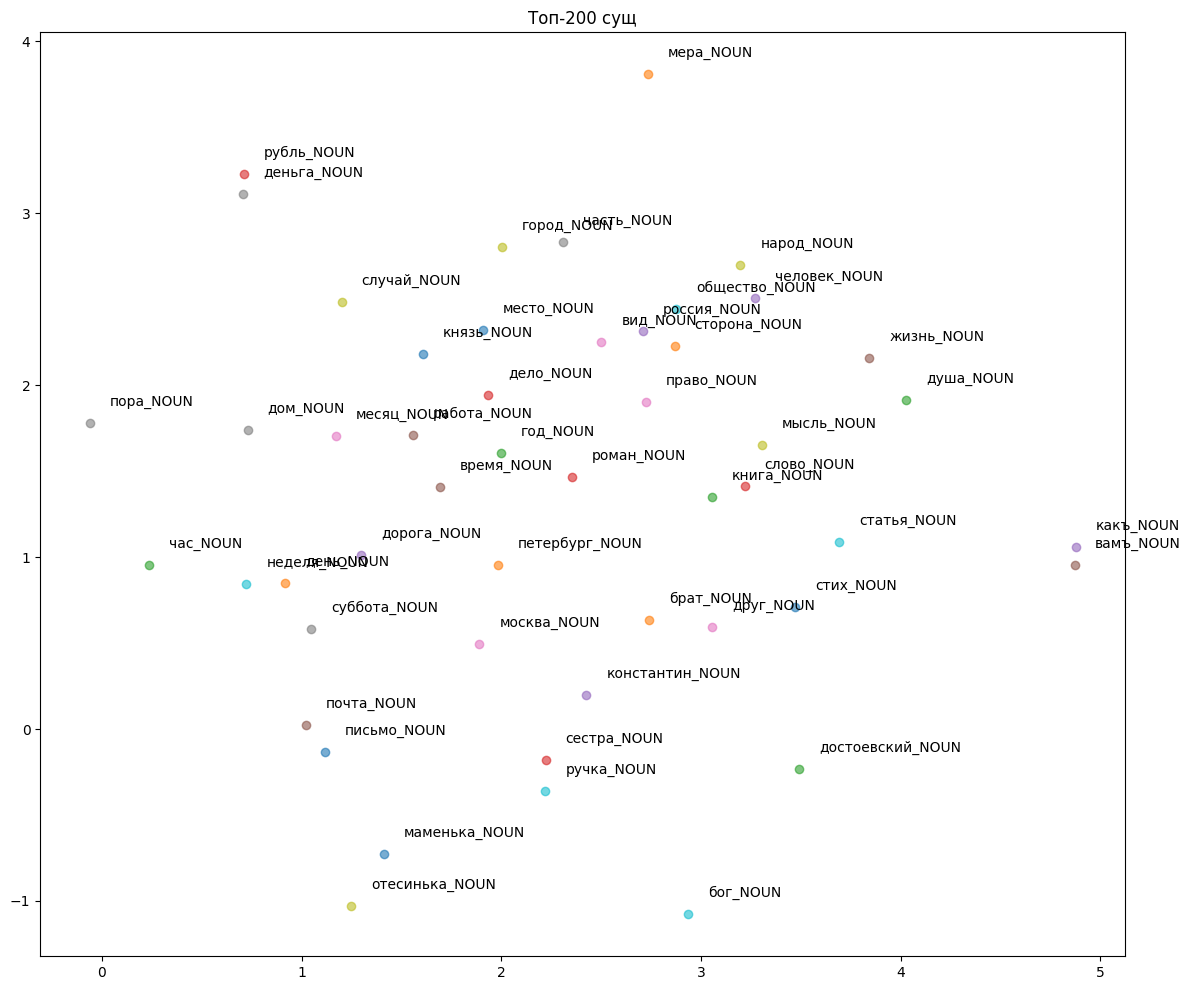

In [127]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 12))
for i, word in enumerate(words_nouns):
    x, y = tsne_vectors[i, :]
    plt.scatter(x, y, marker='o', alpha=0.6)
    plt.text(x + 0.1, y + 0.1, word, fontsize=10)

plt.title("Топ-200 сущ")
plt.show()

То же самое, но с красивой библиотекой plotly.

In [129]:
import plotly.graph_objects as go

fig = go.Figure()
for i, word in enumerate(words_nouns):
    x, y = tsne_vectors[i, :]
    fig.add_trace(
        go.Scatter(
            x=[x],
            y=[y],
            mode="markers+text",
            text=[word],
            textposition="top center",
            marker=dict(size=8, opacity=0.7))
    )

fig.update_layout(
    title="Топ-200 сущ",
    showlegend=False,
    hovermode="closest",
    width=1000,
    height=800,
    template="plotly_white"
)
fig.show()

Теперь посмотрим на окружение отдельных слов.

In [135]:
top_rus = [tupl[0] for tupl in w2v_slavs.wv.most_similar('русский_ADJF', topn=20)]
print(top_rus)

['оглавление_NOUN', 'беседа_NOUN', 'сень_NOUN', 'поговорка_NOUN', 'курзал_NOUN', 'державин_NOUN', 'иностранный_ADJF', 'одиссея_NOUN', 'публика_NOUN', 'язык_NOUN', 'продаваться_PRTF', 'распространить_INFN', 'французский_ADJF', 'закидать_VERB', 'издавать_PRTF', 'поддать_PRTF', 'хвалёный_ADJF', 'кулиш_NOUN', 'литература_NOUN', 'затевать_PRTF']


In [153]:
top_rus.append('русский_ADJF')
vectors = [w2v_slavs.wv[word] for word in top_rus]
vectors = np.array(vectors)
print(vectors)

[[-7.9066172e-02  3.5505492e-02  4.4004861e-02 ...  6.4297155e-02
   2.5361625e-02 -7.2660008e-03]
 [-2.4108855e-01  2.8111279e-01  2.2544664e-01 ...  2.7781576e-01
   2.3790053e-01 -1.9765791e-01]
 [-1.8016987e-02  5.7653249e-03  1.6011586e-02 ...  8.4917434e-03
   1.2981938e-02  3.2754822e-03]
 ...
 [-5.0004125e-02  2.4321429e-02  5.0960496e-02 ...  1.4591640e-02
   8.6570745e-03 -6.0336303e-04]
 [-1.7382604e+00  6.1313283e-01  3.3111802e-01 ...  4.6862561e-01
   5.5919665e-01 -5.3748108e-02]
 [-1.7382604e+00  6.1313283e-01  3.3111802e-01 ...  4.6862561e-01
   5.5919665e-01 -5.3748108e-02]]


In [154]:
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
vectors_2d = tsne.fit_transform(np.array(vectors))

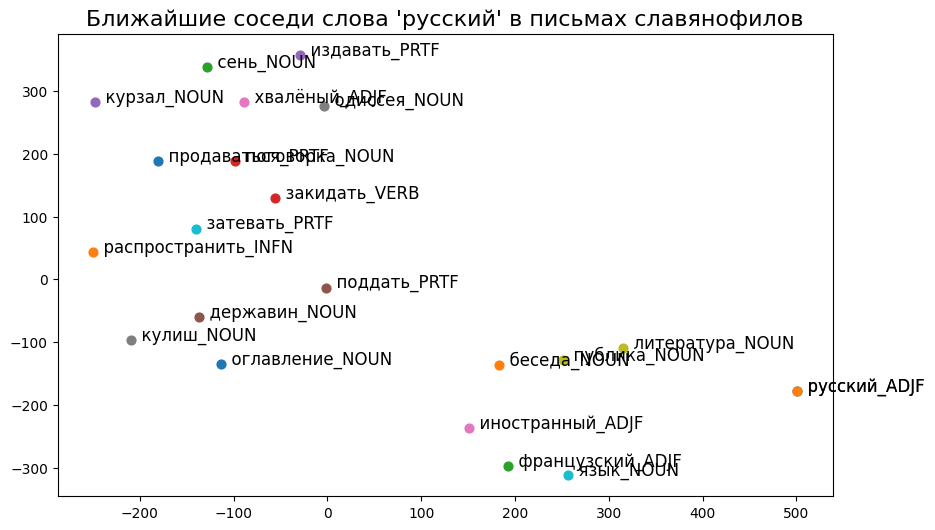

In [156]:
plt.figure(figsize=(10, 6))
for i, word in enumerate(top_rus):
    plt.scatter(vectors_2d[i, 0], vectors_2d[i, 1], s=40)
    plt.annotate("  "+ word, (vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=12)
plt.title("Ближайшие соседи слова 'русский' в письмах славянофилов", fontsize=16)
plt.show()

### Задание
А теперь посмотрите на соседей любого слова в модели, построенной на корпусе писем Билинского.

______
Существуют уже обученные на больших корпусах модели, давайте посмотрим на [эмбеддинги от RusVectores](https://rusvectores.org/en/models/). Скачайте модель ruwikiruscorpora_upos_cbow_300_10_2021.

In [105]:
model = gensim.models.KeyedVectors.load_word2vec_format('model.bin', binary=True)

In [106]:
model.most_similar('любить_VERB')

[('обожать_VERB', 0.7903730273246765),
 ('нравиться_VERB', 0.7554476857185364),
 ('ненавидеть_VERB', 0.682483971118927),
 ('полюбить_VERB', 0.6718093752861023),
 ('любить_ADJ', 0.630898654460907),
 ('любимый_VERB', 0.6209321618080139),
 ('любить_NOUN', 0.6193422675132751),
 ('любовь_NOUN', 0.612057089805603),
 ('любимый_ADJ', 0.6120219230651855),
 ('уважать_VERB', 0.6057565808296204)]

In [ ]:
# а так можно вытащить ближайшего соседа
model.most_similar('любить_VERB')[0][0]

'обожать_VERB'

## Лабораторная работа №3.

Как вы знаете, во время написания художественного текста авторы нередко испытывают муки выбора между тем или иным словом. Все эти правки остаются за кадром: текстологи изучают черновики и моделируют творческий процесс, анализируют замены и пытаются отследить изменения в авторском замысле.

Черновики читать сложно! Но всем однажды хочется заглянуть в закулисье творческого процесса. Давайте напишем текст, которого никогда не было, но который вполне мог бы существовать!

Задача: возьмите отрывок любого художественного текста (абзац или несколько строф). Замените все 
- существительные, 
- глаголы,
- прилагательные

на ближайшие ассоциаты из модели c RusVectores. 


In [ ]:
# сохраните текст, лемматизируйте

In [ ]:
# выберите нужные части речи
# замените эти слова на ближайшие из модели
# выведите альтернативную версию текста